In [1]:
import warnings
import os 
import subprocess 

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  
import torch
import torch.distributions as D

from flow_matching.solver import ODESolver

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

from data import generate_quad_gmm
from model import vf, prior, ConditionedVelocityModelWrapper

torch.manual_seed(42)
device = torch.device("cpu")

In [2]:
# 1. Define the folder and filename
folder_path = './checkpoints/' # Change this to your desired folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

checkpoint_path = os.path.join(folder_path, 'cond_fm.pth')
ckpt = torch.load(checkpoint_path)
vf.load_state_dict(ckpt["vf_state_dict"])
prior.load_state_dict(ckpt["prior_state_dict"])

<All keys matched successfully>

In [3]:
x_1, y, d, diff = generate_quad_gmm(1000)
gaussian_log_density = D.Independent(
    D.Normal(torch.zeros(2, device=device), torch.ones(2, device=device)), 1
).log_prob

# --- split indices once (regression → no stratify) ---
idx = np.arange(len(diff))
diff_np = diff.detach().cpu().numpy() if hasattr(diff, "detach") else np.asarray(diff)
targets = diff_np[:, :2]  # columns 0 and 1

train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=None
)

# helper: one linear regressor (with scaling for stability)
def make_reg():
    return make_pipeline(LinearRegression())


omegas = np.linspace(0, 1, 50)
n_steps = 200

# per-omega, per-timestep R² for each component
omega_series_dim0 = []  # shape after stack: (len(omegas), n_steps)
omega_series_dim1 = []

# (optional) keep fitted models if you want to inspect coefficients later
keep_models = False
models_dim0 = []  # list of lists: models_dim0[i_omega][t]
models_dim1 = []

for omega in omegas:
    wrapped_vf = ConditionedVelocityModelWrapper(velocity_model=vf, cfg_scale=omega)
    solver = ODESolver(velocity_model=wrapped_vf)

    out = solver.compute_likelihood(
        x_1=x_1,
        y=y,
        time_grid=torch.linspace(1, 0, n_steps),
        method="midpoint",
        step_size=None,
        exact_divergence=False,
        log_p0=gaussian_log_density,
        return_intermediates=True,
    )

    r2_d0 = np.empty(len(out[0]), dtype=float)
    r2_d1 = np.empty(len(out[0]), dtype=float)

    if keep_models:
        omega_models_d0 = []
        omega_models_d1 = []

    for t, X_t in enumerate(out[0]):
        Xt = X_t.detach().cpu().numpy() if hasattr(X_t, "detach") else np.asarray(X_t)

        X_train, X_test = Xt[train_idx], Xt[test_idx]
        y0_train, y0_test = targets[train_idx, 0], targets[test_idx, 0]
        y1_train, y1_test = targets[train_idx, 1], targets[test_idx, 1]

        # --- separate models ---
        reg0 = make_reg()
        reg1 = make_reg()

        reg0.fit(X_train, y0_train)
        reg1.fit(X_train, y1_train)

        y0_pred = reg0.predict(X_test)
        y1_pred = reg1.predict(X_test)

        r2_d0[t] = r2_score(y0_test, y0_pred)
        r2_d1[t] = r2_score(y1_test, y1_pred)

        if keep_models:
            omega_models_d0.append(reg0)
            omega_models_d1.append(reg1)

    omega_series_dim0.append(r2_d0)
    omega_series_dim1.append(r2_d1)

    if keep_models:
        models_dim0.append(omega_models_d0)
        models_dim1.append(omega_models_d1)

# reverse time like you did before
omega_series_dim0 = np.stack(omega_series_dim0)[:, ::-1]  # (len(omegas), n_steps)
omega_series_dim1 = np.stack(omega_series_dim1)[:, ::-1]  # (len(omegas), n_steps)

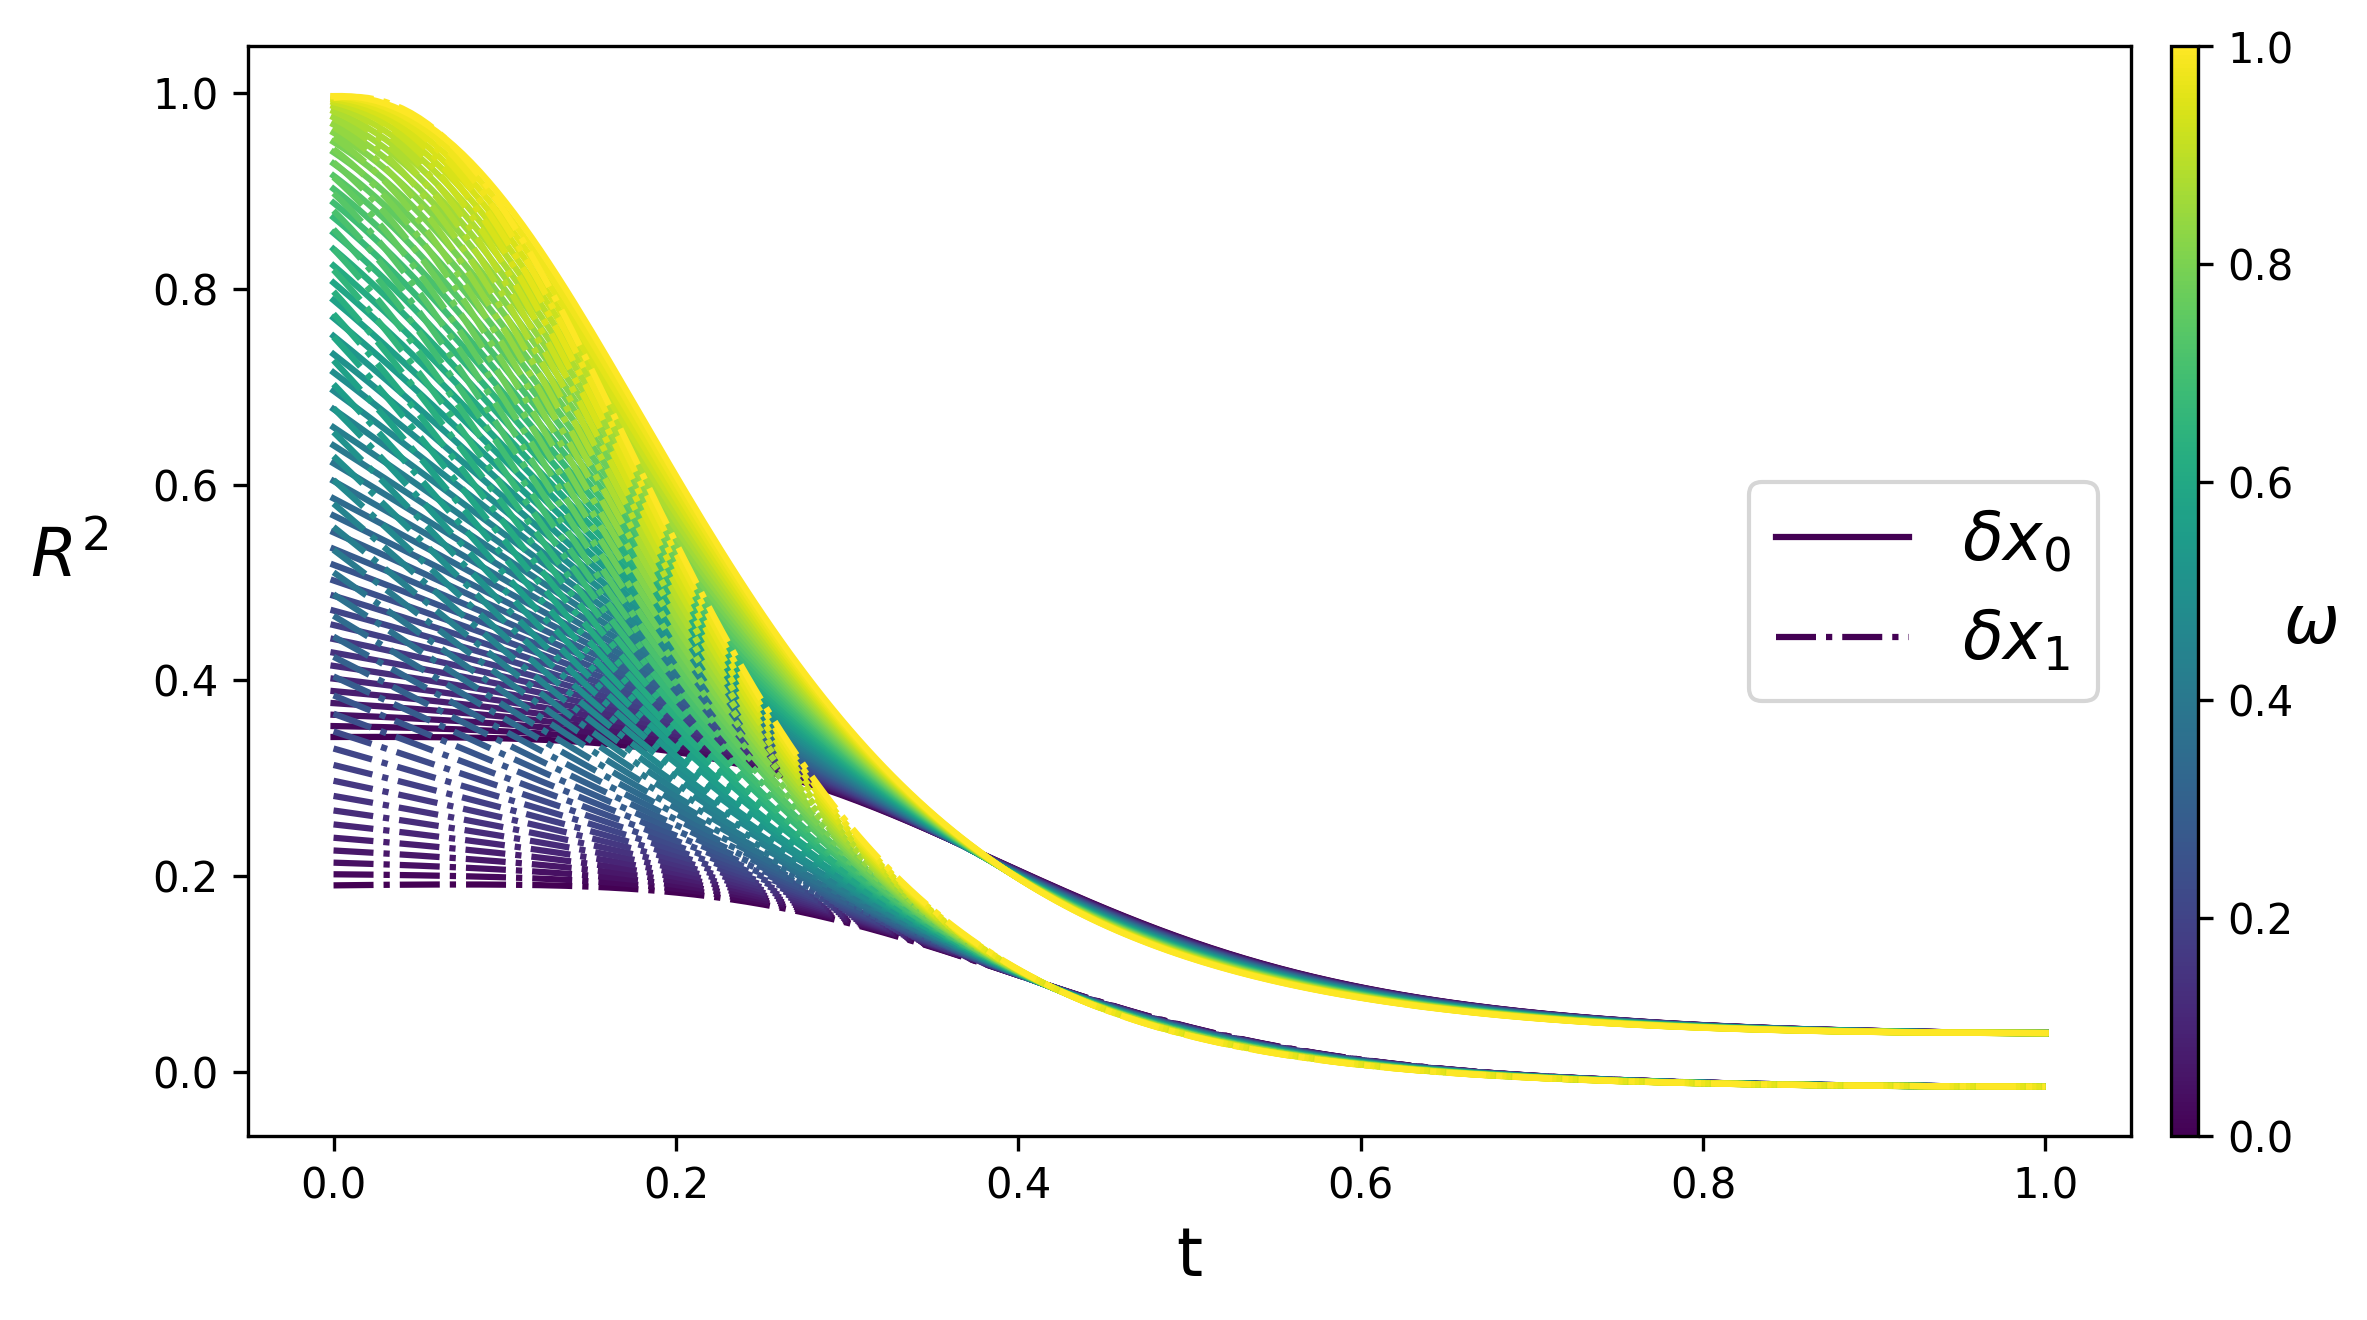

In [6]:
ts = np.linspace(0, 1, n_steps)
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=omegas.min(), vmax=omegas.max())
colors = cmap(norm(omegas))

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

for k in range(len(omegas)):
    ax.plot(ts, omega_series_dim0[k], color=colors[k])
    ax.plot(ts, omega_series_dim1[k], color=colors[k], linestyle="-.")  # same style

ax.set_xlabel("t", fontsize=16)
ax.set_ylabel("$R^2$", fontsize=16, rotation=0, labelpad=20)

ax.legend([r"$\delta{x_0}$", r"$\delta{x_1}$"], fontsize=16, loc="center right")

# Colorbar keyed to omegas
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03, aspect=40)
cbar.set_label(r"$\omega$", fontsize=16, rotation=0)

plt.tight_layout()
plt.show()